In the cell below, we describe the mathematical model and the finite element method used for simulating stationary (time‑independent) incompressible flow in a channel.

---

## 1. Strong Formulation

Let $\Omega \subset \mathbb{R}^2$ be the flow domain with boundary $\partial \Omega$. The stationary incompressible Navier–Stokes equations are given by:

### 1.1. Momentum Equation
$$
-\nu\,\Delta \mathbf{u} + (\mathbf{u}\cdot \nabla)\mathbf{u} + \nabla p = \mathbf{f} \quad \text{in } \Omega,
$$
where:
- $\mathbf{u} = (u_1, u_2)$ is the velocity field,
- $p$ is the pressure,
- $\nu > 0$ is the kinematic viscosity, and
- $\mathbf{f}$ is a given body force (for example, $\mathbf{f} = (1,0)$).

### 1.2. Continuity Equation
$$
\nabla \cdot \mathbf{u} = 0 \quad \text{in } \Omega.
$$

### 1.3. Boundary Conditions

Typical boundary conditions include:
- **Dirichlet (Essential):**  
  $$
  \mathbf{u} = \mathbf{u}_D \quad \text{on } \Gamma_D \subset \partial\Omega,
  $$
- **Neumann (Natural):**  
  $$
  \nu\,\frac{\partial \mathbf{u}}{\partial n} - p\,\mathbf{n} = \mathbf{g} \quad \text{on } \Gamma_N = \partial\Omega \setminus \Gamma_D,
  $$
  
where $\mathbf{n}$ is the outward normal to $\partial \Omega$.

---

## 2. Weak (Variational) Formulation

To derive the weak formulation, we multiply the momentum equation by a vector-valued test function $\mathbf{v}$ (chosen from an appropriate space $V$) and the continuity equation by a test function $q$ (from a space $Q$), and then integrate over $\Omega$.

After integration by parts, the **weak formulation** is:

**Find** $(\mathbf{u}, p) \in V \times Q$ **such that**
$$
\nu \int_{\Omega} \nabla \mathbf{u} : \nabla \mathbf{v}\,dx 
+ \int_{\Omega} (\mathbf{u}\cdot\nabla)\mathbf{u}\cdot \mathbf{v}\,dx 
- \int_{\Omega} p\, (\nabla\cdot \mathbf{v})\,dx 
- \int_{\Omega} q\, (\nabla\cdot \mathbf{u})\,dx
= \int_{\Omega} \mathbf{f}\cdot\mathbf{v}\,dx,
$$
for all $(\mathbf{v}, q) \in V \times Q$.

Here:
- The term $\nabla \mathbf{u} : \nabla \mathbf{v}$ denotes the Frobenius inner product of the gradient matrices.
- Integration by parts transfers derivatives from the trial functions to the test functions and gives rise to boundary integrals, which are handled by the prescribed boundary conditions.

---

## 3. Finite Element Discretization

### 3.1. Finite Element Spaces

To discretize the weak formulation, we choose finite-dimensional subspaces $V_h \subset V$ and $Q_h \subset Q$. A popular choice for incompressible flow problems is the **Taylor–Hood** element pairing:

- **Velocity Space $V_h$:**  
  Typically chosen as a subspace of $[H^1(\Omega)]^2$ consisting of continuous, piecewise polynomials of degree $k$ (e.g., $k=2$ or $k=3$) that satisfy the essential boundary condition on $\Gamma_D$:
  $$
  V_h = \{ \mathbf{v}_h \in [C^0(\Omega)]^2 : \mathbf{v}_h|_K \in [P_k(K)]^2,\ \mathbf{v}_h = \mathbf{u}_D \text{ on } \Gamma_D \}.
  $$
- **Pressure Space $Q_h$:**  
  Typically chosen as a subspace of $H^1(\Omega)$ with continuous, piecewise polynomials of degree $k-1$:
  $$
  Q_h = \{ q_h \in C^0(\Omega) : q_h|_K \in P_{k-1}(K) \}.
  $$

This pairing satisfies the Ladyzhenskaya–Babuška–Brezzi (LBB) condition, ensuring stability in the discrete approximation.

### 3.2. Discrete Weak Formulation

The discrete problem is:

**Find** $(\mathbf{u}_h, p_h) \in V_h \times Q_h$ **such that**
$$
a((\mathbf{u}_h, p_h); (\mathbf{v}_h, q_h)) = L(\mathbf{v}_h, q_h) \quad \forall (\mathbf{v}_h, q_h) \in V_h \times Q_h,
$$
with
$$
\begin{aligned}
a((\mathbf{u}_h, p_h); (\mathbf{v}_h, q_h)) &= \nu \int_{\Omega} \nabla \mathbf{u}_h : \nabla \mathbf{v}_h\,dx 
+ \int_{\Omega} (\mathbf{u}_h\cdot\nabla)\mathbf{u}_h\cdot \mathbf{v}_h\,dx\\[1mm]
&\quad - \int_{\Omega} p_h\, (\nabla\cdot \mathbf{v}_h)\,dx - \int_{\Omega} q_h\, (\nabla\cdot \mathbf{u}_h)\,dx,
\end{aligned}
$$
and
$$
L(\mathbf{v}_h, q_h) = \int_{\Omega} \mathbf{f}\cdot\mathbf{v}_h\,dx.
$$

### 3.3. Assembly and Nonlinear Solution

- **Assembly:**  
  The bilinear and linear forms are assembled into matrices and vectors. In NGSolve, this is done via objects such as `BilinearForm` and `LinearForm`.

- **Nonlinearity:**  
  The convective term $(\mathbf{u}_h\cdot \nabla)\mathbf{u}_h$ introduces nonlinearity. This is typically handled using a Newton-type iterative method. At each iteration, the linearized system is assembled and solved for the update.

- **Dirichlet Conditions:**  
  The Dirichlet conditions are imposed strongly (in a full Dirichlet formulation or using appropriate penalty or Lagrange multiplier techniques) on the parts of the boundary where the velocity is prescribed.

In [3]:
import numpy as np
import pandas as pd
from ngsolve import *
from ngsolve.webgui import *
from netgen.occ import *
from NSSolver import *     # Must contain NSStationary, SimpleNewton, etc.
import matplotlib.pyplot as plt
from IPython.display import display

pi = np.pi

# --- Geometry and Mesh Generation ---
l_x = 4
l_y = 0.5

# Create a rectangle (width l_x, height 2*l_y) and shift it vertically.
# With l_y = 0.5, the rectangle spans y from 0 to 1.
shape = Rectangle(l_x, 2*l_y).Face()
shape = shape.Move((0, -l_y, 0))

# Tag boundaries:
# We'll label the left boundary as "inlet", the right as "outlet", and both the top and bottom as "wall"
shape.edges.Min(X).name = "inlet"
shape.edges.Max(X).name = "outlet"
shape.edges.Min(Y).name = "wall"
shape.edges.Max(Y).name = "wall"

# Generate a 2D mesh from the OCC geometry.
mesh = Mesh(OCCGeometry(shape, dim=2).GenerateMesh(maxh=0.07))


# --- Common Problem Parameters ---
nu = 1e-3               # Kinematic viscosity
f  = CF((1, 0))          # Constant body force driving flow in x-direction

# --- Case 1: Uniform Flow ---
# Here we prescribe u = (1,0) on all boundaries.
ns1 = NSStationary(nu=nu, no_slip="wall|inlet|outlet", full_dirichlet=True)
gfu1 = ns1.solve(mesh, f=f, u_D=CF((1, 0)), order=2, tol=1e-10, maxiter=20)
# Expected: nearly uniform velocity field across the channel.

# --- Case 2: Parabolic Profile (Natural Inlet/Outlet) ---
# Here only the wall is prescribed with no-slip (u = (0,0)); the inlet and outlet are natural.
ns2 = NSStationary(nu=nu, no_slip="wall", full_dirichlet=False)
gfu2 = ns2.solve(mesh, f=f, u_D=CF((0, 0)), order=2, tol=1e-10, maxiter=20)
# Expected: a Poiseuille-like parabolic profile developing in the interior.

# --- Visualization via NGSolve WebGUI ---
# For each case, we display the velocity field (assumed stored in gfu.components[0])
scene_mesh = Draw(mesh, "Mesh")
scene1 = Draw(gfu1.components[0], mesh, "Case 1: Uniform Flow (u=(1,0) everywhere)")
scene2 = Draw(gfu2.components[0], mesh, "Case 2: Parabolic Profile (no-slip on wall)")

# In a Jupyter Notebook, use display() to show the WebGL scenes inline.
display(scene_mesh)
display(scene1)
display(scene2)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

BaseWebGuiScene

BaseWebGuiScene

# Convergence Analysis for the Stationary Navier–Stokes Equations

This section explains the mathematical theory behind the convergence analysis code provided below. In convergence studies, manufactured solutions—exact solutions chosen a priori—are used to verify that a numerical method converges at the expected rate as the mesh is refined. For the stationary Navier–Stokes equations, we assess convergence by computing error norms between the computed discrete solution and the manufactured (exact) solution.

---

## 1. Manufactured Solutions

We consider two manufactured cases:

### Case 1: Uniform Flow
The exact solution is chosen as:
$$
\mathbf{u}_{\text{exact}} = (1,0), \quad p_{\text{exact}} = 0.
$$
Since the velocity is constant, its gradient vanishes:
$$
\nabla \mathbf{u}_{\text{exact}} = \begin{pmatrix} 0 & 0 \\ 0 & 0 \end{pmatrix}.
$$

### Case 2: Parabolic Profile
A typical profile for fully developed channel flow is a parabolic profile. In this case, the exact solution is:
$$
\mathbf{u}_{\text{exact}} = \bigl(4\,y\,(1-y),\,0\bigr), \quad p_{\text{exact}} = 0.
$$
The only nonzero derivative is:
$$
\frac{\partial u_x}{\partial y} = 4\,(1-2\,y),
$$
with the other entries in the gradient matrix equal to zero.

These manufactured solutions serve two purposes:
- They can be used to enforce Dirichlet boundary conditions.
- They provide a reference against which the error of the numerical solution is measured.

---

## 2. Error Norms

To quantify the accuracy of the computed solution, the following error norms are defined:

### 2.1. Velocity \(L^2\) Norm
The error in the velocity is measured in the \(L^2\) norm:
$$
\| \mathbf{u}_h - \mathbf{u}_{\text{exact}} \|_{L^2(\Omega)} = \sqrt{\int_{\Omega} \left|\mathbf{u}_h - \mathbf{u}_{\text{exact}}\right|^2\,dx}.
$$
In the code, the function `compute_norms` computes this norm by integrating the square of the pointwise difference over the domain.

### 2.2. Velocity Gradient Norm
To assess the error in the shear (or strain) rate, a weighted gradient norm is computed:
$$
\| \nabla (\mathbf{u}_h - \mathbf{u}_{\text{exact}}) \|_{L^2(\Omega)} = \sqrt{\nu \int_{\Omega} \left\| \nabla (\mathbf{u}_h - \mathbf{u}_{\text{exact}}) \right\|^2\,dx},
$$
where \(\nu\) is the kinematic viscosity. This norm penalizes errors in the gradient of the velocity, which is especially important for viscous flows.

### 2.3. Pressure \(L^2\) Norm
The pressure error is measured by:
$$
\| p_h - p_{\text{exact}} \|_{L^2(\Omega)} = \sqrt{\int_{\Omega} \left|p_h - p_{\text{exact}}\right|^2\,dx}.
$$
Since the pressure is defined only up to an additive constant, its error may be measured relative to a suitable normalization.

---

## 3. Convergence Analysis Procedure

The convergence analysis proceeds as follows:

1. **Mesh Refinement:**  
   A list of maximum mesh sizes, \( h \), is specified. For each \( h \), a new mesh is generated from the given geometry (in our case, a rectangle of width 4 and height 1).

2. **Discrete Problem Solution:**  
   For each mesh, the stationary Navier–Stokes problem is solved using an instance of the solver (here, an object of class `NSStationary`). In the convergence study, the Dirichlet data \( u_D \) is set equal to the exact solution. In an ideal scenario, if the numerical method were exact, the computed solution would match the manufactured solution exactly.

3. **Error Computation:**  
   With the computed solution (denoted by \( \mathbf{u}_h \) and \( p_h \)), the following error measures are computed:
   - **Velocity \(L^2\) Error:**  
     $$ E_{L^2}^u = \| \mathbf{u}_h - \mathbf{u}_{\text{exact}} \|_{L^2(\Omega)}. $$
   - **Velocity Gradient Error:**  
     $$ E_{\nabla}^u = \| \nabla (\mathbf{u}_h - \mathbf{u}_{\text{exact}}) \|_{L^2(\Omega)}. $$
   - **Pressure \(L^2\) Error:**  
     $$ E_{L^2}^p = \| p_h - p_{\text{exact}} \|_{L^2(\Omega)}. $$

4. **Experimental Order of Convergence (EOC):**  
   The EOC between two successive mesh refinements is defined by
   $$
   \text{EOC} = \frac{\log\left(\frac{E_{k-1}}{E_k}\right)}{\log(f)},
   $$
   where \( E_k \) is the error for mesh size \( h_k \) and \( f \) is the refinement factor (typically \( f = 2 \) if the mesh size is halved). Functions `EOC` and `compute_convergence_table` in the code calculate these values and organize them into a table.

5. **Data Organization:**  
   The errors for each mesh size and the corresponding EOC values are stored in a pandas DataFrame, which is printed out. This provides a quantitative measure of how quickly the error decreases as the mesh is refined.

---

## 4. Finite Element Discretization and Solver

The stationary Navier–Stokes equations are discretized using a Taylor–Hood element pairing:
- **Velocity space \(V_h\):** A subspace of \([H^1(\Omega)]^2\) consisting of continuous, piecewise polynomials of degree \(k\) (e.g., \(k=2\)).
- **Pressure space \(Q_h\):** A subspace of \(H^1(\Omega)\) with continuous, piecewise polynomials of degree \(k-1\).

The discrete weak formulation seeks \((\mathbf{u}_h, p_h) \in V_h \times Q_h\) such that
$$
a((\mathbf{u}_h, p_h); (\mathbf{v}_h, q_h)) = L(\mathbf{v}_h, q_h) \quad \forall (\mathbf{v}_h, q_h) \in V_h \times Q_h,
$$
with the bilinear form
$$
\begin{aligned}
a((\mathbf{u}_h, p_h); (\mathbf{v}_h, q_h)) &= \nu \int_{\Omega} \nabla \mathbf{u}_h : \nabla \mathbf{v}_h\,dx + \int_{\Omega} (\mathbf{u}_h\cdot\nabla)\mathbf{u}_h\cdot \mathbf{v}_h\,dx\\[1mm]
&\quad - \int_{\Omega} p_h\, (\nabla\cdot \mathbf{v}_h)\,dx - \int_{\Omega} q_h\, (\nabla\cdot \mathbf{u}_h)\,dx,
\end{aligned}
$$
and the linear form
$$
L(\mathbf{v}_h, q_h) = \int_{\Omega} \mathbf{f}\cdot\mathbf{v}_h\,dx.
$$

The nonlinearity introduced by the convective term is handled via an iterative method (e.g., Newton’s method). The Dirichlet boundary conditions are imposed strongly on the parts of the boundary where the solution is prescribed.


In [6]:
import numpy as np
import pandas as pd
from ngsolve import *
from netgen.occ import *
import math

# Manufactured Solutions for Convergence Study
# ----------------------------------------------
# Case 1: Uniform Flow (Exact solution: u = (1,0), p = 0)
u_exact_case1 = CF((1, 0))
grad_u_exact_case1 = CF(((0, 0), (0, 0)))  # Zero gradient everywhere
p_exact_case1 = CF(0)

# Case 2: Parabolic Profile (Exact solution: u = (4y(1-y),0), p = 0)
u_exact_case2 = CF((4 * y * (1 - y), 0))
# Gradient of u: only the derivative of u_x with respect to y is nonzero.
grad_u_exact_case2 = CF(((0, 4 * (1 - 2 * y)), (0, 0)))
p_exact_case2 = CF(0)


def compute_norms(mesh, u_h, u_exact, grad_u_exact=None, nu=1e-3):
    """
    Compute the L2 norm of the error for u, and (if provided) the weighted gradient error.
    
    Returns:
      If grad_u_exact is provided: (L2_error, grad_error)
      Otherwise: L2_error.
    """
    L2_error = math.sqrt(Integrate((u_h - u_exact) * (u_h - u_exact), mesh))
    if grad_u_exact is not None:
        grad_error = math.sqrt(nu * Integrate(Norm(grad(u_h) - grad_u_exact)**2, mesh))
        return L2_error, grad_error
    return L2_error


def convergence_analysis(mesh_sizes, shape, NS_Object, u_exact, grad_u_exact, p_exact, order=2,
                         rhs=CF((0,0)), g_neu=CF((0,0)), neu_region=None, nu=1e-3):
    """
    For a list of mesh sizes, generate the mesh, solve the NS problem using NS_Object,
    and compute the errors for the velocity (in L2 and gradient norm) and for the pressure.
    
    Returns a pandas DataFrame with mesh size and errors.
    """
    u_L2_errors = []
    u_grad_errors = []
    p_L2_errors = []
    hs = []
    
    for h in mesh_sizes:
        # Generate mesh with maxh = h:
        mesh_i = Mesh(OCCGeometry(shape, dim=2).GenerateMesh(maxh=h))
        
        # Solve the problem (here u_D is set equal to the exact solution, to measure the error).
        gfu = NS_Object.solve(
            mesh_i,
            f=rhs,
            u_D=u_exact,
            order=order,
            nonlinear_solver=simple_newton,
            tol=1e-10,
            maxiter=30,
            g_neu=g_neu,
            neu_region=neu_region
        )
        
        # Extract velocity (u_h) and pressure (p_h).
        u_h, p_h = gfu.components[:2]
        
        # Compute velocity errors:
        uL2, uGrad = compute_norms(mesh_i, u_h, u_exact, grad_u_exact, nu=nu)
        u_L2_errors.append(uL2)
        u_grad_errors.append(uGrad)
        
        # Compute pressure L2 error.
        pL2 = compute_norms(mesh_i, p_h, p_exact)
        p_L2_errors.append(pL2)
        
        hs.append(h)
    
    data = {
        'mesh_size': hs,
        'L2_norm_u': u_L2_errors,
        'Gradient_norm_u': u_grad_errors,
        'L2_norm_p': p_L2_errors
    }
    df = pd.DataFrame(data)
    return df


def EOC(df, norm_name, fac=2):
    """
    Compute the Experimental Order of Convergence (EOC) for the error norm given in norm_name.
    
    Parameters:
      df        : DataFrame with error values.
      norm_name : Column name (string) for which to compute EOC.
      fac       : Refinement factor (default 2).
      
    Returns:
      List of EOC values between successive mesh refinements.
    """
    errors = df[norm_name].values
    eoc_vals = []
    for k in range(1, len(errors)):
        eoc = np.log(errors[k-1] / errors[k]) / np.log(fac)
        eoc_vals.append(eoc)
    return eoc_vals


def compute_convergence_table(df, fac=2):
    """
    Build a pivot table (DataFrame) of the EOC values for the various norms.
    """
    eoc_data = {
        'L2_norm_u': EOC(df, 'L2_norm_u', fac),
        'Gradient_norm_u': EOC(df, 'Gradient_norm_u', fac),
        'L2_norm_p': EOC(df, 'L2_norm_p', fac)
    }
    index = np.arange(1, len(df))
    eoc_df = pd.DataFrame(eoc_data, index=index)
    return eoc_df


# ---------------------------
# Set Up Geometry for Convergence Study
# ---------------------------
l_x = 4
l_y = 0.5
shape = Rectangle(l_x, 2*l_y).Face().Move((0, -l_y, 0))
shape.edges.Min(X).name = "inlet"
shape.edges.Max(X).name = "outlet"
shape.edges.Min(Y).name = "wall"
shape.edges.Max(Y).name = "wall"

# ---------------------------
# Choose a list of mesh sizes (maxh)
# ---------------------------
mesh_sizes = [0.14, 0.10, 0.07, 0.05]

# ---------------------------
# Convergence Analysis for Case 1 (Uniform Flow)
# ---------------------------
# For uniform flow, NS_Object should enforce u = (1,0) on all boundaries.
NS_obj_case1 = NSStationary(nu=1e-3, no_slip="wall|inlet|outlet", full_dirichlet=True)
df_case1 = convergence_analysis(mesh_sizes, shape, NS_obj_case1, u_exact_case1,
                                grad_u_exact_case1, p_exact_case1, order=2, nu=1e-3)
print("Convergence analysis for Case 1 (Uniform Flow):")
print(df_case1)
print("EOC (velocity L2 norm):", EOC(df_case1, 'L2_norm_u'))
print("EOC (velocity gradient norm):", EOC(df_case1, 'Gradient_norm_u'))
print("EOC (pressure L2 norm):", EOC(df_case1, 'L2_norm_p'))

# ---------------------------
# Convergence Analysis for Case 2 (Parabolic Profile)
# ---------------------------
# For the parabolic profile, we assume natural inlet/outlet so that the exact solution is u = (4y(1-y),0).
NS_obj_case2 = NSStationary(nu=1e-3, no_slip="wall", full_dirichlet=False)
df_case2 = convergence_analysis(mesh_sizes, shape, NS_obj_case2, u_exact_case2,
                                grad_u_exact_case2, p_exact_case2, order=2, nu=1e-3)
print("Convergence analysis for Case 2 (Parabolic Profile):")
print(df_case2)
print("EOC (velocity L2 norm):", EOC(df_case2, 'L2_norm_u'))
print("EOC (velocity gradient norm):", EOC(df_case2, 'Gradient_norm_u'))
print("EOC (pressure L2 norm):", EOC(df_case2, 'L2_norm_p'))

# Optionally, compute a pivot table for the EOC values:
eoc_table_case1 = compute_convergence_table(df_case1, fac=2)
eoc_table_case2 = compute_convergence_table(df_case2, fac=2)
print("EOC Table for Case 1:")
print(eoc_table_case1)
print("EOC Table for Case 2:")
print(eoc_table_case2)

Convergence analysis for Case 1 (Uniform Flow):
   mesh_size     L2_norm_u  Gradient_norm_u     L2_norm_p
0       0.14  5.872076e+01     9.989681e+01  8.984277e+02
1       0.10  3.822150e+02     9.291729e+02  9.814740e+03
2       0.07  4.136894e-16     9.181039e-16  1.166424e-16
3       0.05  5.085018e-16     1.156538e-15  9.963314e-17
EOC (velocity L2 norm): [-2.7024418624561366, 59.680542222675236, -0.2977048624977971]
EOC (velocity gradient norm): [-3.2174365592216008, 59.811995414091065, -0.3330838195870461]
EOC (pressure L2 norm): [-3.449475751739907, 66.18949142592923, 0.22739484307140514]
Convergence analysis for Case 2 (Parabolic Profile):
   mesh_size   L2_norm_u  Gradient_norm_u     L2_norm_p
0       0.14   40.039937        65.136849    166.735532
1       0.10  125.057478       294.311413   1467.996766
2       0.07  261.141426       870.194322  14760.859656
3       0.05  334.280215      1584.574169  22114.187349
EOC (velocity L2 norm): [-1.6430797082073714, -1.062240012221527

## 1. Transient Navier–Stokes Equations

The time‐dependent, incompressible Navier–Stokes equations in a domain $\Omega \subset \mathbb{R}^2$ with boundary $\partial \Omega$ are given by:

### 1.1. Momentum Equation
$$
\frac{\partial \mathbf{u}}{\partial t} - \nu \Delta \mathbf{u} + (\mathbf{u} \cdot \nabla)\mathbf{u} + \nabla p = \mathbf{f} \quad \text{in } \Omega \times (0, T],
$$
where:
- $\mathbf{u} = (u_1, u_2)$ is the velocity field,
- $p$ is the pressure,
- $\nu > 0$ is the kinematic viscosity,
- $\mathbf{f}$ is a prescribed body force (e.g. $\mathbf{f} = (1,0)$).

### 1.2. Continuity Equation
$$
\nabla \cdot \mathbf{u} = 0 \quad \text{in } \Omega \times (0, T].
$$

### 1.3. Initial and Boundary Conditions

An initial condition is prescribed:
$$
\mathbf{u}(x,0) = \mathbf{u}_0(x) \quad \text{in } \Omega.
$$

Boundary conditions are given on $\partial\Omega$. For example:
- **Dirichlet (Essential) Conditions:**  
  $$
  \mathbf{u} = \mathbf{u}_D \quad \text{on } \Gamma_D \subset \partial\Omega,
  $$
- **Neumann (Natural) Conditions:**  
  $$
  \nu\,\frac{\partial \mathbf{u}}{\partial n} - p\,\mathbf{n} = \mathbf{g} \quad \text{on } \Gamma_N = \partial\Omega \setminus \Gamma_D,
  $$
where $\mathbf{n}$ is the outward unit normal to $\partial\Omega$.

In our study, two sets of boundary conditions are considered:
- **Case 1 (Uniform Flow):** The Dirichlet condition $\mathbf{u}=(1,0)$ is enforced on all boundaries.
- **Case 2 (Parabolic Profile):** The no‑slip condition $\mathbf{u}=(0,0)$ is enforced only on the walls, while the inlet and outlet are left natural.

---

## 2. Time Discretization

The transient problem is discretized in time using a time-stepping method such as the Backward Differentiation Formula (BDF). For instance, using first-order BDF (BDF1), the time derivative is approximated as:
$$
\frac{\partial \mathbf{u}}{\partial t}(t_{n+1}) \approx \frac{\mathbf{u}^{n+1} - \mathbf{u}^n}{\Delta t},
$$
where \(\Delta t\) is the time step and \(\mathbf{u}^n\) denotes the solution at time \(t_n\). The discrete momentum equation then becomes:
$$
\frac{\mathbf{u}^{n+1} - \mathbf{u}^n}{\Delta t} - \nu \Delta \mathbf{u}^{n+1} + (\mathbf{u}^{n+1}\cdot\nabla)\mathbf{u}^{n+1} + \nabla p^{n+1} = \mathbf{f}^{n+1},
$$
with the incompressibility constraint enforced at each time step:
$$
\nabla \cdot \mathbf{u}^{n+1} = 0.
$$

Nonlinearity, due to the convective term $(\mathbf{u}^{n+1}\cdot\nabla)\mathbf{u}^{n+1}$, is typically handled with a Newton-type iterative method.

---

## 3. Finite Element Discretization

### 3.1. Finite Element Spaces

We discretize the spatial domain using a Taylor–Hood element pairing:
- **Velocity Space \(V_h\):**  
  A subspace of $[H^1(\Omega)]^2$ composed of continuous, piecewise polynomials of degree $k$ that satisfy the prescribed Dirichlet conditions:
  $$
  V_h = \{ \mathbf{v}_h \in [C^0(\Omega)]^2 : \mathbf{v}_h|_K \in [P_k(K)]^2, \; \mathbf{v}_h = \mathbf{u}_D \text{ on } \Gamma_D \}.
  $$
- **Pressure Space \(Q_h\):**  
  A subspace of \(H^1(\Omega)\) consisting of continuous, piecewise polynomials of degree \(k-1\):
  $$
  Q_h = \{ q_h \in C^0(\Omega) : q_h|_K \in P_{k-1}(K) \}.
  $$

This choice satisfies the Ladyzhenskaya–Babuška–Brezzi (LBB) condition, which is crucial for ensuring stability in the numerical approximation of incompressible flows.

### 3.2. Discrete Weak Formulation

At each time step, the discrete weak formulation seeks $(\mathbf{u}_h^{n+1}, p_h^{n+1}) \in V_h \times Q_h$ such that for all test functions $(\mathbf{v}_h, q_h) \in V_h \times Q_h$,
$$
\begin{aligned}
\frac{1}{\Delta t} \int_{\Omega} (\mathbf{u}_h^{n+1} - \mathbf{u}_h^n) \cdot \mathbf{v}_h \, dx &+ \nu \int_{\Omega} \nabla \mathbf{u}_h^{n+1} : \nabla \mathbf{v}_h \, dx \\
&+ \int_{\Omega} (\mathbf{u}_h^{n+1}\cdot \nabla)\mathbf{u}_h^{n+1} \cdot \mathbf{v}_h \, dx \\
&- \int_{\Omega} p_h^{n+1}\, (\nabla\cdot\mathbf{v}_h) \, dx - \int_{\Omega} q_h\, (\nabla\cdot\mathbf{u}_h^{n+1}) \, dx \\
&= \int_{\Omega} \mathbf{f}^{n+1}\cdot \mathbf{v}_h\, dx.
\end{aligned}
$$

Here, the term
$$
\frac{1}{\Delta t} \int_{\Omega} (\mathbf{u}_h^{n+1} - \mathbf{u}_h^n) \cdot \mathbf{v}_h \, dx
$$
approximates the time derivative, while the other terms represent the viscous, convective, and pressure contributions.

The system is nonlinear due to the convective term and is solved iteratively at each time step using, for example, a Newton method.

In [4]:
import numpy as np
import pandas as pd
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from NSSolver import NS_Solver  # This wrapper should call one of the BDF solvers
import matplotlib.pyplot as plt
from IPython.display import display

pi = np.pi

# --- Geometry and Mesh Generation ---
l_x = 4
l_y = 0.5

# Create a rectangle (width l_x, height 2*l_y) and shift it vertically.
# With l_y = 0.5, the domain spans y from 0 to 1.
shape = Rectangle(l_x, 2*l_y).Face()
shape = shape.Move((0, -l_y, 0))

# Tag boundaries:
# Left boundary is "inlet", right is "outlet", and both top and bottom are "wall".
shape.edges.Min(X).name = "inlet"
shape.edges.Max(X).name = "outlet"
shape.edges.Min(Y).name = "wall"
shape.edges.Max(Y).name = "wall"

# Generate a 2D mesh from the OCC geometry.
mesh = Mesh(OCCGeometry(shape, dim=2).GenerateMesh(maxh=0.07))


# --- Common Problem Parameters for Transient Simulation ---
nu   = 1e-3              # Kinematic viscosity
f_const = lambda t: CF((1, 0))   # Constant body force (in x-direction)
dt   = 0.1               # Time step size
T    = 1.0               # Final time

# --- Helper: Create a Taylor-Hood FE Space ---
def create_fes(mesh, no_slip, full_dirichlet, order=2):
    V = VectorH1(mesh, order=order, dirichlet=no_slip)
    Q = H1(mesh, order=order-1)
    fes = V * Q
    if full_dirichlet:
        fes = fes * NumberSpace(mesh)
    return fes

# --- Case 1: Uniform Flow ---
# All boundaries are prescribed with u = (1,0).
no_slip1 = "wall|inlet|outlet"
full_dirichlet1 = True
u_D1 = lambda t: CF((1, 0))
fes1 = create_fes(mesh, no_slip1, full_dirichlet1, order=2)
gfu1 = NS_Solver(mesh, fes1, u_D=u_D1, f=f_const, nu=nu, dt=dt, T=T,
                 no_slip=no_slip1, full_dirichlet=full_dirichlet1,
                 method='BDF1_NEWTON')
scene1 = Draw(gfu1.components[0], mesh, "Case 1: Uniform Flow (u=(1,0) everywhere)")
display(scene1)

# --- Case 2: Parabolic Profile ---
# Only the wall is enforced as no-slip (u=(0,0)); inlet and outlet remain natural.
no_slip2 = "wall"
full_dirichlet2 = False
u_D2 = lambda t: CF((0, 0))
fes2 = create_fes(mesh, no_slip2, full_dirichlet2, order=2)
gfu2 = NS_Solver(mesh, fes2, u_D=u_D2, f=f_const, nu=nu, dt=dt, T=T,
                 no_slip=no_slip2, full_dirichlet=full_dirichlet2,
                 method='BDF1_NEWTON')
#scene2 = Draw(gfu2.components[0], mesh, "Case 2: Parabolic Profile (no-slip on wall)")
scene2 = Draw(gfu2.components[0], mesh, interpolate_multidim=True, animate=True, min=0, max=2, autoscale=False)

display(scene2)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## 1. Manufactured (Exact) Solutions

Two manufactured cases are considered:

### Case 1: Uniform Flow
The exact solution is defined as
$$
\mathbf{u}_{\text{exact}}(t) = (1,0), \quad p_{\text{exact}}(t) = 0.
$$
Since the velocity is constant, its gradient is identically zero:
$$
\nabla \mathbf{u}_{\text{exact}}(t) = \begin{pmatrix} 0 & 0 \\ 0 & 0 \end{pmatrix}.
$$

### Case 2: Parabolic Profile
A common profile for channel flow is a parabolic profile. In this case, the exact solution is given by
$$
\mathbf{u}_{\text{exact}}(t) = \bigl(4\,y(1-y),\,0\bigr), \quad p_{\text{exact}}(t) = 0.
$$
Here, the only nonzero derivative is
$$
\frac{\partial u_{x}}{\partial y} = 4(1-2y),
$$
while all other entries in the gradient are zero.

These manufactured solutions serve as benchmarks for comparing the computed numerical solution against the known exact solution.

---

## 2. Error Norms

To quantify the discrepancy between the computed solution and the exact solution, several error norms are used:

### 2.1. Velocity \(L^2\) Norm
The error in the velocity is measured by the \(L^2\) norm over the spatial domain:
$$
\| \mathbf{u}_h(t) - \mathbf{u}_{\text{exact}}(t) \|_{L^2(\Omega)} = \sqrt{\int_{\Omega} \left|\mathbf{u}_h(t) - \mathbf{u}_{\text{exact}}(t)\right|^2\,dx}.
$$
In the analysis, a "maximum in time" version is computed:
$$
E_{L^2}^{\infty} = \max_{t \in [0,T]} \| \mathbf{u}_h(t) - \mathbf{u}_{\text{exact}}(t) \|_{L^2(\Omega)}.
$$

### 2.2. Velocity Gradient Norm
To measure the error in the velocity gradient (which is critical for viscous flows), a weighted norm is defined:
$$
E_{\nabla}^u = \sqrt{\nu \int_{\Omega} \left\| \nabla (\mathbf{u}_h(t) - \mathbf{u}_{\text{exact}}(t)) \right\|^2\,dx},
$$
where \(\nu\) is the kinematic viscosity. This norm is integrated over time to assess the overall error in the strain rates.

### 2.3. Pressure \(L^2\) Norm
The pressure error is quantified by
$$
E_{L^2}^p = \| p_h(t) - p_{\text{exact}}(t) \|_{L^2(\Omega)} = \sqrt{\int_{\Omega} \left|p_h(t) - p_{\text{exact}}(t)\right|^2\,dx}.
$$
Note that pressure is defined up to an additive constant, so care is needed in its interpretation.

---

## 3. Convergence Analysis Procedure

The convergence study proceeds with the following steps:

1. **Mesh Refinement:**  
   A sequence of mesh sizes (denoted by the maximum element size \(h\)) is chosen (e.g., \(h \in \{0.14, 0.10, 0.07, 0.05\}\)). For each mesh size, a new mesh is generated from the given geometry (here, a rectangle with width 4 and height 1).

2. **Transient Problem Solution:**  
   For each mesh, the transient Navier–Stokes problem is solved over the time interval \([0, T]\) (with a time step \(\Delta t\)). In the convergence study, the Dirichlet boundary data \(u_D\) is set equal to the manufactured solution \( \mathbf{u}_{\text{exact}} \). This ensures that the error, ideally, would vanish if the numerical method were exact.

3. **Error Computation:**  
   After solving, the following errors are computed:
   - **Velocity Error:**  
     $$ E_{L^2}^{\infty} = \max_{n} \sqrt{\int_{\Omega} |\mathbf{u}_h^n - \mathbf{u}_{\text{exact}}(t_n)|^2\,dx} $$
   - **Velocity Gradient Error:**  
     $$ E_{\nabla}^u = \sqrt{\nu \sum_{n} \int_{\Omega} \|\nabla (\mathbf{u}_h^n - \mathbf{u}_{\text{exact}}(t_n))\|^2\,dx}, $$
   - **Pressure Error:**  
     $$ E_{L^2}^p = \sqrt{\sum_{n} \int_{\Omega} |p_h^n - p_{\text{exact}}(t_n)|^2\,dx}. $$

   These norms are computed by integrating the squared differences over the domain at each time step and, for the velocity, taking the maximum over time.

4. **Experimental Order of Convergence (EOC):**  
   The EOC is computed between successive mesh refinements as
   $$
   \text{EOC} = \frac{\log\left(E_{k-1}/E_k\right)}{\log(2)},
   $$
   assuming that the mesh size is halved (refinement factor \(f=2\)). This gives a quantitative measure of the rate at which the error decreases as the mesh is refined.

5. **Data Organization:**  
   The computed errors and EOC values are assembled into a pandas DataFrame, which provides a clear summary of how the numerical error decreases with mesh refinement.

In [ ]:
import numpy as np
import pandas as pd
from ngsolve import *
from netgen.occ import *
from NSSolver import NS_Solver  # Assumes NS_Solver is defined to solve the transient NS problem
import math

pi = np.pi

# ---------------------------
# Geometry Setup
# ---------------------------
l_x = 4
l_y = 0.5

# Create a rectangle (width l_x, height 2*l_y) and shift it vertically
# (with l_y = 0.5, the domain spans y from 0 to 1)
shape = Rectangle(l_x, 2*l_y).Face()
shape = shape.Move((0, -l_y, 0))

# Tag boundaries: left = "inlet", right = "outlet", top and bottom = "wall"
shape.edges.Min(X).name = "inlet"
shape.edges.Max(X).name = "outlet"
shape.edges.Min(Y).name = "wall"
shape.edges.Max(Y).name = "wall"

# ---------------------------
# Problem Parameters for Transient Simulation
# ---------------------------
nu = 1e-3                            # Kinematic viscosity
f_const = lambda t: CF((1, 0))         # Constant body force (in x-direction)
dt_val = 0.1                         # Time step size
T_val = 1.0                          # Final time

# For convergence analysis, we refine the mesh; we choose a list of maximum element sizes:
mesh_sizes = [0.14, 0.10, 0.07, 0.05]
# For simplicity, we use the same dt for all mesh sizes.
dt_list = [dt_val for _ in mesh_sizes]

# ---------------------------
# Manufactured Exact Solutions
# ---------------------------
# Case 1: Uniform Flow
u_exact_case1 = lambda t: CF((1, 0))
grad_u_exact_case1 = lambda t: CF(((0,0),(0,0)))  # Zero gradient
p_exact_case1 = lambda t: CF(0)

# Case 2: Parabolic Profile
u_exact_case2 = lambda t: CF((4 * y * (1 - y), 0))
# Only u_x is nonzero; its y-derivative is 4*(1-2*y)
grad_u_exact_case2 = lambda t: CF(((0, 4*(1-2*y)), (0,0)))
p_exact_case2 = lambda t: CF(0)

# ---------------------------
# Helper Functions for Error Computation
# ---------------------------
def LinfL2Norm(u_h, u_ex, mesh, dt, T):
    """
    Computes a "max" L2 norm error over time:
      norm = sqrt( max_t ∫_mesh |u_h(t)-u_ex(t)|^2 dx ).
    Assumes u_h has a method MDComponent(n) to extract the n-th time step.
    """
    norm = Integrate((u_h.MDComponent(0) - u_ex(0))*(u_h.MDComponent(0) - u_ex(0)), mesh)
    t = 0
    n = 0
    while t < T:
        t += dt
        n += 1
        current = Integrate((u_h.MDComponent(n) - u_ex(t))*(u_h.MDComponent(n) - u_ex(t)), mesh)
        norm = max(norm, current)
    return np.sqrt(norm)

def L2VNorm(u_h, grad_u_ex, mesh, dt, T, nu=1, order=2):
    """
    Computes the velocity gradient error norm:
      sqrt( nu * ∫_0^T ∫_mesh |grad(u_h(t)) - grad(u_ex(t))|^2 dx dt ).
    """
    V = VectorH1(mesh, order=order)
    u_temp = GridFunction(V)
    u_temp.Set(u_h.MDComponent(0))
    norm = Integrate((grad(u_temp) - grad_u_ex(0))**2, mesh)
    t = 0
    n = 0
    while t < T:
        t += dt
        n += 1
        u_temp.Set(u_h.MDComponent(n))
        norm += Integrate((grad(u_temp) - grad_u_ex(t))**2, mesh)
    return np.sqrt(norm * nu)

def L2QNorm(p_h, p_ex, mesh, dt, T, nu=1, order=1):
    """
    Computes the L2 norm error for the pressure:
      sqrt( ∫_0^T ∫_mesh |p_h(t)-p_ex(t)|^2 dx dt / nu ).
    """
    Q = H1(mesh, order=order)
    p_temp = GridFunction(Q)
    p_temp.Set(p_ex(0))
    norm = Integrate((p_temp - p_ex(0))*(p_temp - p_ex(0)), mesh)
    t = 0
    n = 0
    while t < T:
        t += dt
        n += 1
        # p_h.MDComponent(n) extracts the nth time slice.
        norm += Integrate((p_h.MDComponent(n) - p_ex(t))**2, mesh)
    return np.sqrt(norm / nu)

def convergence_analysis_transient(h_list, dt_list, T, shape, u_exact, grad_u_exact, p_exact,
                                   f=lambda t: CF((0,0)), nu=1, no_slip=None, full_dirichlet=False,
                                   g=lambda t: CF((0,0)), do_nothing=None, tol=1e-11, maxiter=30, 
                                   method='BDF1_NEWTON', order=2):
    """
    For each mesh size in h_list, generate a mesh and solve the transient NS problem using NS_Solver.
    Then, compute the following error norms over time:
      - LinfL2 norm for the velocity.
      - L2 norm for the velocity gradient (weighted by nu).
      - L2 norm for the pressure.
    Returns a pandas DataFrame containing the errors for each mesh size.
    """
    LinfL2_u_errors = []
    L2V_u_errors = []
    L2Q_p_errors = []
    for i in range(len(h_list)):
        # Generate mesh for current size.
        mesh_i = Mesh(OCCGeometry(shape, dim=2).GenerateMesh(maxh=h_list[i]))
        
        # Build FE space.
        V = VectorH1(mesh_i, order=order, dirichlet=no_slip)
        Q = H1(mesh_i, order=order-1)
        fes = V * Q
        if full_dirichlet:
            fes = fes * NumberSpace(mesh_i)
        
        # Solve transient NS problem.
        gfut = NS_Solver(mesh_i, fes, u_0=u_exact(0), u_D=u_exact, f=f,
                         dt=dt_list[i], T=T, no_slip=no_slip, full_dirichlet=full_dirichlet,
                         nu=nu, g=g, do_nothing=do_nothing, method=method,
                         maxiter=maxiter, tol=tol)
        # Extract velocity and pressure components.
        u_h, p_h = gfut.components[:2]
        
        # Compute errors.
        error_LinfL2 = LinfL2Norm(u_h, u_exact, mesh_i, dt_list[i], T)
        error_L2V  = L2VNorm(u_h, grad_u_exact, mesh_i, dt_list[i], T, nu=nu, order=order)
        error_L2Q  = L2QNorm(p_h, p_exact, mesh_i, dt_list[i], T, nu=nu, order=order-1)
        
        LinfL2_u_errors.append(error_LinfL2)
        L2V_u_errors.append(error_L2V)
        L2Q_p_errors.append(error_L2Q)
        
        # Optionally refine mesh for the next iteration.
        mesh_i.Refine()
    
    data = {
        'mesh_size': h_list,
        'LinfL2Norm_u': LinfL2_u_errors,
        'L2VNorm_u': L2V_u_errors,
        'L2QNorm_p': L2Q_p_errors
    }
    df = pd.DataFrame(data)
    return df

def EOC(df, norm_name, fac=2):
    """
    Compute the Experimental Order of Convergence (EOC) for a specified error norm.
    Returns a list of EOC values computed between successive mesh refinements.
    """
    errors = df[norm_name].values
    eoc_vals = []
    for k in range(1, len(errors)):
        eoc = np.log(errors[k-1] / errors[k]) / np.log(fac)
        eoc_vals.append(eoc)
    return eoc_vals

def compute_convergence_table(df, fac=2):
    """
    Create a pivot table (DataFrame) containing the EOC values for the velocity L2 norm,
    velocity gradient norm, and pressure L2 norm.
    """
    eoc_data = {
        'LinfL2Norm_u': EOC(df, 'LinfL2Norm_u', fac),
        'L2VNorm_u': EOC(df, 'L2VNorm_u', fac),
        'L2QNorm_p': EOC(df, 'L2QNorm_p', fac)
    }
    index = np.arange(1, len(df))
    eoc_df = pd.DataFrame(eoc_data, index=index)
    return eoc_df

# ---------------------------
# Manufactured Solutions for Transient Convergence Study
# ---------------------------
# Case 1: Uniform Flow (exact solution: u = (1,0), p = 0)
u_exact_case1 = lambda t: CF((1, 0))
grad_u_exact_case1 = lambda t: CF(((0,0),(0,0)))
p_exact_case1 = lambda t: CF(0)

# Case 2: Parabolic Profile (exact solution: u = (4*y*(1-y),0), p = 0)
u_exact_case2 = lambda t: CF((4 * y * (1 - y), 0))
grad_u_exact_case2 = lambda t: CF(((0, 4*(1-2*y)), (0, 0)))
p_exact_case2 = lambda t: CF(0)

# ---------------------------
# Run Convergence Analysis for the Transient Case
# ---------------------------
# Here, we perform the study for both manufactured solutions.
print("Convergence analysis for transient Case 1 (Uniform Flow):")
df_case1 = convergence_analysis_transient(mesh_sizes, dt_list, T, shape,
                                          u_exact_case1, grad_u_exact_case1, p_exact_case1,
                                          f=f_const, nu=nu, no_slip="wall|inlet|outlet", full_dirichlet=True,
                                          method='BDF1_NEWTON', order=2)
print(df_case1)
print("EOC for velocity L2 norm (Case 1):", EOC(df_case1, 'LinfL2Norm_u'))
print("EOC for velocity gradient norm (Case 1):", EOC(df_case1, 'L2VNorm_u'))
print("EOC for pressure L2 norm (Case 1):", EOC(df_case1, 'L2QNorm_p'))

print("\nConvergence analysis for transient Case 2 (Parabolic Profile):")
df_case2 = convergence_analysis_transient(mesh_sizes, dt_list, T, shape,
                                          u_exact_case2, grad_u_exact_case2, p_exact_case2,
                                          f=f_const, nu=nu, no_slip="wall", full_dirichlet=False,
                                          method='BDF1_NEWTON', order=2)
print(df_case2)
print("EOC for velocity L2 norm (Case 2):", EOC(df_case2, 'LinfL2Norm_u'))
print("EOC for velocity gradient norm (Case 2):", EOC(df_case2, 'L2VNorm_u'))
print("EOC for pressure L2 norm (Case 2):", EOC(df_case2, 'L2QNorm_p'))

# Optionally, create pivot tables for the EOC values:
eoc_table_case1 = compute_convergence_table(df_case1, fac=2)
eoc_table_case2 = compute_convergence_table(df_case2, fac=2)
print("\nEOC Table for transient Case 1:")
print(eoc_table_case1)
print("\nEOC Table for transient Case 2:")
print(eoc_table_case2)

## JUST PLAYING AROUND... FLOW AROUND AN OBJECT IN THE FLOWPATH

In [5]:
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from NSSolver import *   # (Optional: if you have additional solver wrappers)
import ipywidgets as widgets
import matplotlib.pyplot as plt

# ---------------------------
# Geometry and Mesh Generation
# ---------------------------
# Define the Schäfer–Turek benchmark geometry:
# A rectangle of width 2 and height 0.41 with a circular hole (cut out) at (0.2,0.2) of radius 0.05.
shape = Rectangle(2, 0.41).Circle(0.2, 0.2, 0.05).Reverse().Face()
# Tag all edges initially as "wall"
shape.edges.name = "wall"
# Set the left boundary as "inlet" and right boundary as "outlet"
shape.edges.Min(X).name = "inlet"
shape.edges.Max(X).name = "outlet"

# Visualize the geometry (if desired)
Draw(shape, "Geometry")

# Generate a 2D mesh from the OCC geometry and raise its polynomial order (here Curve(3)):
mesh = Mesh(OCCGeometry(shape, dim=2).GenerateMesh(maxh=0.07)).Curve(3)
Draw(mesh, "Mesh")

# ---------------------------
# Finite Element Setup
# ---------------------------
# Use a higher order Taylor-Hood pairing:
# - Velocity in VectorH1 of order 3 (with Dirichlet conditions on inlet and wall)
# - Pressure in H1 of order 2
V = VectorH1(mesh, order=3, dirichlet="wall|inlet")
Q = H1(mesh, order=2)
X = V * Q  # Product space

# Trial and test functions:
u, p = X.TrialFunction()
v, q = X.TestFunction()

# Set the viscosity
nu = 0.001

# ---------------------------
# Steady Stokes Problem for Initial Conditions
# ---------------------------
# Define the parabolic inflow profile at the inlet:
# u_in = (1.5*4*y*(0.41-y)/(0.41^2), 0)
uin = CoefficientFunction((1.5 * 4 * y * (0.41 - y) / (0.41 * 0.41), 0))

# Create a GridFunction for the solution.
gfu = GridFunction(X)
# Apply the parabolic inflow on the inlet.
gfu.components[0].Set(uin, definedon=mesh.Boundaries("inlet"))
Draw(gfu.components[0], mesh, "Initial Inflow Velocity")

# Assemble the Stokes bilinear form:
a = BilinearForm(X)
a += (nu * InnerProduct(grad(u), grad(v))
      + div(u) * q + div(v) * p
      - 1e-10 * p * q) * dx
a.Assemble()

# Assemble a (zero) right-hand side linear form.
f = LinearForm(X)
f.Assemble()

# Solve the steady Stokes system:
inv_stokes = a.mat.Inverse(X.FreeDofs())
res = f.vec - a.mat * gfu.vec
gfu.vec.data += inv_stokes * res
Draw(gfu.components[0], mesh, "Steady State (Initial Conditions)")

# ---------------------------
# Transient Navier–Stokes Time-Stepping
# ---------------------------
# We now use an IMEX Euler splitting method to evolve the solution.
# (Here, we use the convective term explicitly and the rest implicitly.)
tau = 0.001     # Time step
tend = 10       # Final time
t = 0
i = 0

# Prepare an auxiliary mass bilinear form (for the time-stepping)
m = BilinearForm(X)
m += u * v * dx
m.Assemble()

# The non-linear convective term (to be applied explicitly)
conv = BilinearForm(X, nonassemble=True)
conv += (Grad(u) * u) * v * dx

# Prepare a modified Stokes bilinear form from the steady problem:
# (This is used in the implicit part)
# We reuse the previously assembled Stokes operator "a" from the steady Stokes solve.
# For the time-stepping, we assemble a mass-plus-stokes operator:
mstar = BilinearForm(X)
mstar += InnerProduct(u, v) * dx + tau * (nu * InnerProduct(grad(u), grad(v))
                                          - div(u) * q - div(v) * p
                                          - 1e-10 * p * q) * dx
mstar.Assemble()
inv = mstar.mat.Inverse(X.FreeDofs(), inverse="sparsecholesky")

# Prepare a multi-dimensional GridFunction to store time steps.
gfut = GridFunction(V, multidim=0)
gfut.AddMultiDimComponent(gfu.components[0].vec)

# Set up a WebGUI scene for live visualization.
scene = Draw(gfu.components[0], mesh, min=0, max=2, autoscale=False)
tw = widgets.Text(value='t = 0')
display(tw)

with TaskManager():
    while t < tend:
        # Explicitly compute the convective residual
        conv.Assemble()
        res = conv.Apply(gfu.vec) + a.mat * gfu.vec
        # Update the solution using implicit Euler step:
        gfu.vec.data -= tau * inv * res
        
        t += tau
        i += 1
        
        if i % 10 == 0:
            scene.Redraw()
        if i % 50 == 0:
            gfut.AddMultiDimComponent(gfu.components[0].vec)
        if i % 100 == 0:
            tw.value = "t = " + str(round(t, 3))
    tw.value = "t = " + str(tend) 

# Animate the collected time steps:
Draw(gfut.components[0], mesh, interpolate_multidim=True, animate=True, min=0, max=2, autoscale=False)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Text(value='t = 0')

craete bilinearformapplication


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

# Mathematical Model for Charged Particle Deposition in a Flow with an Electric Field

In this section, we describe a mathematical model for the transport and deposition of charged particles in a fluid flow. The particles are advected by the fluid velocity (obtained from the Navier–Stokes solution) and are additionally influenced by an externally imposed electric field. As the particles move with the water through the electric field, they are attracted to (and eventually deposit on) the metallic wall, which is assumed to be flat in a 2D setting. Below, we outline the key equations and forces that govern this process.

---

## 1. Advection-Diffusion-Drift Equation for Particle Concentration

Let \( c(x,t) \) denote the concentration of charged particles in the fluid at position \( x \in \Omega \) and time \( t \). The evolution of \( c \) can be modeled by an advection-diffusion equation with an additional drift term accounting for the influence of the electric field. The equation reads:
$$
\frac{\partial c}{\partial t} + \nabla \cdot \left( \mathbf{u}\, c \right) + \nabla \cdot \left( \mathbf{v}_E\, c \right) = D \Delta c,
$$
where:
- \( \mathbf{u}(x,t) \) is the fluid velocity field (obtained by solving the Navier–Stokes equations),
- \( \mathbf{v}_E(x) \) is the drift velocity induced by the electric field,
- \( D \) is the diffusion coefficient of the particles in the fluid.

The drift velocity \( \mathbf{v}_E \) is typically given by:
$$
\mathbf{v}_E = \mu_e \, \mathbf{E},
$$
where:
- \( \mu_e \) is the electrophoretic mobility of the particles,
- \( \mathbf{E} = -\nabla \phi \) is the electric field (with \(\phi\) being the electric potential).

---

## 2. Boundary Conditions and Deposition Kinetics

### 2.1. Flux Boundary Condition at the Wall

At the wall (denoted by \( \Gamma_w \)), the particles may deposit. The net flux \( J \) of particles toward the wall is given by:
$$
J = -D \frac{\partial c}{\partial n} + c \, (\mathbf{u} + \mathbf{v}_E) \cdot \mathbf{n},
$$
where:
- \( \frac{\partial c}{\partial n} \) is the normal derivative of \( c \) at the wall,
- \( \mathbf{n} \) is the unit outward normal vector to the wall (pointing out of the fluid).

### 2.2. Deposition (Accumulation) Kinetics on the Wall

Let \( \theta(x,t) \) represent the deposited layer (e.g., the mass or thickness of the deposit) on the wall. A simple kinetic model for the deposition process is:
$$
\frac{\partial \theta}{\partial t} = k_d\, c_w,
$$
where:
- \( k_d \) is a deposition rate constant,
- \( c_w \) is the concentration of particles at the wall (i.e., \( c_w = c(x,t)|_{\Gamma_w} \)).

Alternatively, one can impose a boundary condition that directly relates the flux \( J \) to the rate of change of \( \theta \), for example:
$$
-D \frac{\partial c}{\partial n} + c \, (\mathbf{u} + \mathbf{v}_E) \cdot \mathbf{n} = \frac{\partial \theta}{\partial t} \quad \text{on } \Gamma_w.
$$

---

## 3. Summary of the Model

The evolution of the particle concentration in the fluid is governed by the advection-diffusion-drift equation:
$$
\frac{\partial c}{\partial t} + \nabla \cdot (\mathbf{u}\, c) + \nabla \cdot (\mu_e\, \mathbf{E}\, c) = D \Delta c.
$$
At the wall, the deposition process is modeled through a flux boundary condition or a kinetic equation:
$$
-D \frac{\partial c}{\partial n} + c \, (\mathbf{u} + \mu_e\, \mathbf{E}) \cdot \mathbf{n} = \frac{\partial \theta}{\partial t}.
$$

In our simulation, the fluid velocity \( \mathbf{u}(x,t) \) is obtained by solving the transient Navier–Stokes equations using a finite element method. The computed velocity field is then used to advect the particles, while the imposed electric field produces an additional drift, leading to the deposition of charged particles on the wall over time.

This framework forms the basis for simulating how a layer of deposited particles develops on the metal surfaces forming the wall of the pipe under the combined influence of fluid flow and an electric field.

# Solving a simplified System

Step 1/8000, time=0.01, c_wall=4.5046e-03, deposit=9.0093e-05
Step 2/8000, time=0.02, c_wall=1.5407e-03, deposit=1.2091e-04
Step 3/8000, time=0.03, c_wall=9.1356e-04, deposit=1.3918e-04
Step 4/8000, time=0.04, c_wall=7.4061e-04, deposit=1.5399e-04
Step 5/8000, time=0.05, c_wall=6.6457e-04, deposit=1.6728e-04
Step 6/8000, time=0.06, c_wall=6.1494e-04, deposit=1.7958e-04
Step 7/8000, time=0.07, c_wall=5.7597e-04, deposit=1.9110e-04
Step 8/8000, time=0.08, c_wall=5.4373e-04, deposit=2.0197e-04
Step 9/8000, time=0.09, c_wall=5.1661e-04, deposit=2.1231e-04
Step 10/8000, time=0.10, c_wall=4.9364e-04, deposit=2.2218e-04
Step 11/8000, time=0.11, c_wall=4.7410e-04, deposit=2.3166e-04
Step 12/8000, time=0.12, c_wall=4.5744e-04, deposit=2.4081e-04
Step 13/8000, time=0.13, c_wall=4.4319e-04, deposit=2.4967e-04
Step 14/8000, time=0.14, c_wall=4.3099e-04, deposit=2.5829e-04
Step 15/8000, time=0.15, c_wall=4.2055e-04, deposit=2.6670e-04
Step 16/8000, time=0.16, c_wall=4.1162e-04, deposit=2.7494e-04
S

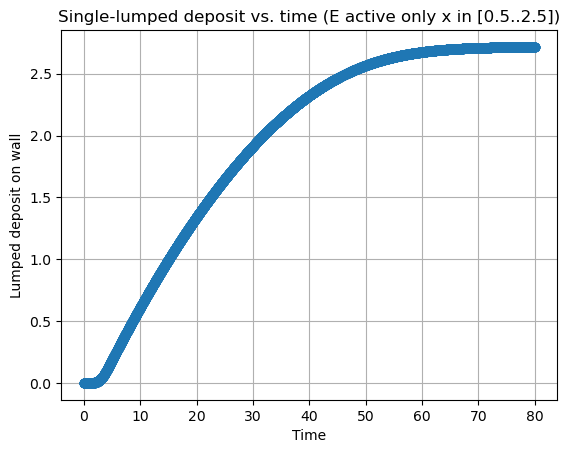

Plot done. You can switch time-steps in the GUI.


In [1]:
import netgen.meshing as meshing
from netgen.geom2d import SplineGeometry
from ngsolve import *
from ngsolve.solvers import GMRes
from ngsolve.la import BaseMatrix
from ngsolve.webgui import Draw

import numpy as np
import matplotlib.pyplot as plt

class IdentityPreconditioner(BaseMatrix):
    """
    Minimal 'Identity' preconditioner so GMRes can do: pre*x => x.
    """
    def __init__(self, size):
        super().__init__()
        self._size = size
    def Height(self): return self._size
    def Width(self):  return self._size
    def Mult(self, x, y):
        # y = x
        y.data = x


def SolveKineticDeposition_WithRemoval(
    mesh,
    velocity_cf,
    E_cf,
    D=1e-3,
    mu_e=1e-1,
    dt=0.01,
    T=2.0,
    c0_value=0.5,
    inflow_c=1.0,
    kd=1.0
):
    """
    Solve the PDE:
        ∂c/∂t + ∇·((u + mu_e·E) c) = D·Δc   in Ω,
    with a boundary removal flux:  -k_d·c  on "wall" (top/bottom boundary).
    
    We track a single “lumped deposit” by integrating c along "wall" at each step
    and subtracting from c with the flux.  The final 'deposit' is stored in deposit_history.
    The solution c at each time step is stored in c_timeline.
    """
    fes_c = H1(mesh, order=1, dirichlet="inflow")
    c_gf = GridFunction(fes_c, "c")
    
    # Set initial c in the domain
    c_gf.Set(c0_value)
    # Overwrite inflow boundary x=0 with c=inflow_c
    c_gf.Set(inflow_c, definedon=mesh.Boundaries("inflow"))

    lumps_deposit = 0.0

    u = fes_c.TrialFunction()
    v = fes_c.TestFunction()

    # Mass matrix
    mass = BilinearForm(fes_c, symmetric=True)
    mass += u*v*dx
    mass.Assemble()

    # Combine velocity + scaled E
    drift_cf = velocity_cf + mu_e * E_cf

    # PDE bilinear form
    a = BilinearForm(fes_c, symmetric=False)
    # diffusion
    a += D * InnerProduct(grad(u), grad(v)) * dx
    # advection + drift
    a += (drift_cf * grad(u)) * v * dx
    # boundary flux => + k_d·u·v on "wall", for removal flux (the PDE side sees +k_d)
    a += kd * u * v * ds("wall")

    a.Assemble()

    mat = mass.mat.CreateMatrix()
    mat.AsVector().data = mass.mat.AsVector() + dt*a.mat.AsVector()

    # We'll do an identity preconditioner + GMRes; or a direct solver if you prefer
    pre = IdentityPreconditioner(mat.height)

    old_sol = c_gf.vec.CreateVector()
    old_sol.data = c_gf.vec
    rhs_vec = c_gf.vec.CreateVector()

    # We'll store the solution in a multi-dim GF for post-processing
    c_timeline = GridFunction(fes_c, multidim=0)
    c_timeline.AddMultiDimComponent(c_gf.vec)

    times = []
    deposit_history = []

    nsteps = int(T / dt)

    for step in range(nsteps):
        tcur = (step+1)*dt

        # implicit Euler: (M + dt*A)*c^(n+1) = M*c^n
        rhs_vec.data = mass.mat * old_sol
        c_gf.vec.data = 0.0 * c_gf.vec

        # Solve with GMRes
        GMRes(
            A=mat,
            b=rhs_vec,
            x=c_gf.vec,
            pre=pre,
            maxsteps=1000,
            tol=1e-8,
            restart=1000,
            printrates=False
        )
        if step % 100 == 0:
            c_timeline.AddMultiDimComponent(c_gf.vec)
        old_sol.data = c_gf.vec

        # measure average c on the "wall", assume top boundary length ~ 1
        c_int = Integrate(c_gf, mesh, BND, definedon=mesh.Boundaries("wall"))
        c_wall = c_int  # if total length is 1

        lumps_deposit += dt * kd * (c_wall)
        times.append(tcur)
        deposit_history.append(lumps_deposit)

        print(f"Step {step+1}/{nsteps}, time={tcur:.2f}, c_wall={c_wall:.4e}, deposit={lumps_deposit:.4e}")

    return c_timeline, times, deposit_history


if __name__=="__main__":
    # 1) Build a simple rectangle geometry: [0,3]x[0,1]
    geo = SplineGeometry()
    geo.AddRectangle((0,0),(3,1), bcs=["inflow","wall","outflow","wall"])
    mesh = Mesh(geo.GenerateMesh(maxh=0.02))

    # 2) Define velocity in x and a piecewise E in y that is active only for x in [0.5, 2.5]
    from ngsolve import x, y, IfPos

    # velocity is parabolic in y
    velocity_cf = CoefficientFunction((4*y*(1-y), 0))

    # E_switch = 1 if 0.5 <= x <= 2.5, else 0
    E_switch = IfPos(x-0.5,        # condition1: x>0.5
                     IfPos(2.5 - x, # condition2: x<2.5
                           1.0,
                           0.0),
                     0.0)
    # Then define E = (0, E_switch), so it's in the y-direction but only active in [0.5..2.5]
    E_cf = CoefficientFunction((0, E_switch))

    # 3) Solve PDE with boundary removal
    #    You can pick T=2, dt=0.01, etc. for a quick run
    c_hist, times, deposit_hist = SolveKineticDeposition_WithRemoval(
        mesh=mesh,
        velocity_cf=velocity_cf,
        E_cf=E_cf,
        D=1e-3,
        mu_e=1e-1,   # scale for E
        dt=0.01,
        T=80.0,
        c0_value=0.5,
        inflow_c=1.0,
        kd=2.0
    )
    print("Solver finished. Final lumps deposit=", deposit_hist[-1])

    # 4) Plot lumps deposit vs time
    plt.figure()
    plt.plot(times, deposit_hist, marker='o', linestyle='--')
    plt.xlabel("Time")
    plt.ylabel("Lumped deposit on wall")
    plt.title("Single-lumped deposit vs. time (E active only x in [0.5..2.5])")
    plt.grid(True)
    plt.savefig("Scurve.png")
    plt.show()

    # 5) Visualize the solution in NGSolve
    Draw(c_hist, mesh, "c_timeline")
    print("Plot done. You can switch time-steps in the GUI.")


# Decomposition profile

/var/folders/mk/4mjy11c91yj95qwrm69075100000gq/T/ipykernel_12458/3795752581.py:77: RuntimeWarning: divide by zero encountered in divide
  (1.0 - ya) / (ya_new - ya),


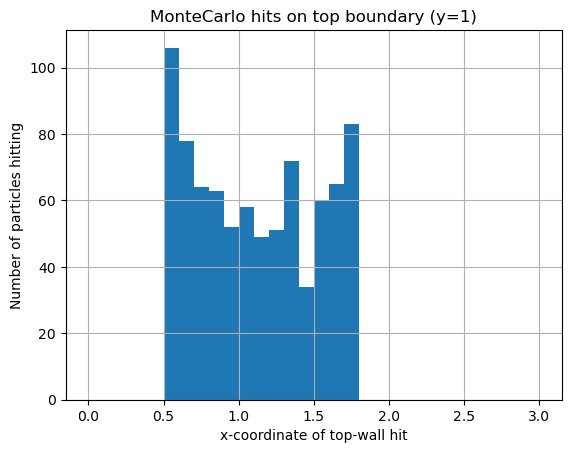

Number of hits: 835
Example hits (first 20): [1.75574282 1.53022036 0.80268322        nan 0.76727879 0.52100455
 0.62022354 1.50424654        nan 0.73793697 1.22231504 1.62923076
 0.54540306 1.10801447 0.87745203 1.17915584        nan 0.57191307
 0.50905892 1.7278046 ]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ngsolve import Mesh, CoefficientFunction, IfPos

def MonteCarloHitDistribution(
    mesh,
    velocity_cf,
    E_cf,
    mu_e=1.0,
    nparticles=2000,
    dt=0.001,
    max_time=2.0,
    show_plot=True
):
    """
    Estimate where charged particles 'hit' the top wall y=1
    by a simple Monte-Carlo/particle-tracing approach.
    
    mesh         : ngsolve.Mesh
    velocity_cf  : ngsolve.CoefficientFunction, e.g. (u_x, u_y)
    E_cf         : ngsolve.CoefficientFunction, e.g. (E_x, E_y) 
                   but possibly zero outside an interval of x.
    mu_e         : electrophoretic mobility factor.
    nparticles   : number of particles to simulate.
    dt           : time-step for the ODE integration (simple Euler).
    max_time     : end time; particles not hitting y=1 by then are missed.
    show_plot    : if True, produce a histogram at the end.
    
    Returns
    -------
    hits_x : 1D numpy array of x-locations of top-wall hits, or NaN if missed.
    """

    # 1) Initial positions: all at x=0, y~Uniform(0..1)
    y0 = np.random.rand(nparticles)
    x0 = np.zeros(nparticles)

    # store current positions
    xs = x0.copy()
    ys = y0.copy()

    # final "hit" x-locations
    hits_x = np.full(nparticles, np.nan)

    nsteps = int(max_time / dt)

    for step in range(nsteps):
        active = np.isnan(hits_x)  # those not yet hitting the top
        if not np.any(active):
            break

        xa = xs[active]
        ya = ys[active]

        vx_vals = np.empty_like(xa)
        vy_vals = np.empty_like(xa)
        Ex_vals = np.empty_like(xa)
        Ey_vals = np.empty_like(xa)

        # Evaluate velocity and E for each particle
        for i in range(len(xa)):
            vx_vals[i], vy_vals[i] = velocity_cf(mesh(xa[i], ya[i]))
            Ex_vals[i], Ey_vals[i] = E_cf(mesh(xa[i], ya[i]))

        # Add drift = mu_e * E
        vx_vals += mu_e * Ex_vals
        vy_vals += mu_e * Ey_vals

        # Euler step
        xa_new = xa + dt * vx_vals
        ya_new = ya + dt * vy_vals

        # check crossing of y=1
        crossing = (ya < 1.0) & (ya_new >= 1.0)

        fraction = np.where(crossing,
                            (1.0 - ya) / (ya_new - ya),
                            0.0)
        x_hit = xa + fraction*(xa_new - xa)

        idx_active = np.where(active)[0]
        idx_cross = idx_active[crossing]
        hits_x[idx_cross] = x_hit[crossing]

        # update positions only for those not crossing
        xa[~crossing] = xa_new[~crossing]
        ya[~crossing] = ya_new[~crossing]
        xs[active] = xa
        ys[active] = ya

    if show_plot:
        valid = hits_x[~np.isnan(hits_x)]
        plt.figure()
        plt.hist(valid, bins=30, range=(0,3))
        plt.xlabel("x-coordinate of top-wall hit")
        plt.ylabel("Number of particles hitting")
        plt.title("MonteCarlo hits on top boundary (y=1)")
        plt.grid(True)
        plt.savefig("MonteCarloHits.png")
        plt.show()

    return hits_x


if __name__ == "__main__":
    from netgen.geom2d import SplineGeometry

    # 1) Domain geometry: [0,3] x [0,1]
    geo = SplineGeometry()
    geo.AddRectangle((0,0),(3,1), bcs=["inflow","wall","outflow","wall"])
    mesh = Mesh(geo.GenerateMesh(maxh=0.02))

    # 2) Define velocity and piecewise E.  E=0 outside [0.5..2.5]
    from ngsolve import x, y

    velocity_cf = CoefficientFunction((4*y*(1-y), 0))

    # IfPos( x-0.5,   IfPos( 2.5-x, 1.0, 0.0 ),  0.0 )
    # that is 1.0 only if (x>=0.5 AND x<=2.5), else 0.0
    E_switch = IfPos(x - 0.5,
                     IfPos(2.5 - x, 1.0, 0.0),
                     0.0)

    # The field is in y-direction with magnitude E_switch
    E_cf = CoefficientFunction((0, E_switch))

    # 3) Run Monte-Carlo
    hits = MonteCarloHitDistribution(
        mesh=mesh,
        velocity_cf=velocity_cf,
        E_cf=E_cf,
        mu_e=0.5,          # scale factor for E
        nparticles=1000,
        dt=0.005,
        max_time=3.0,
        show_plot=True
    )
    print("Number of hits:", np.count_nonzero(~np.isnan(hits)))
    print("Example hits (first 20):", hits[:20])


# Consentration Gradient Analysis


Running for mu_e = 0.5, kd = 5.0, T = 10.0


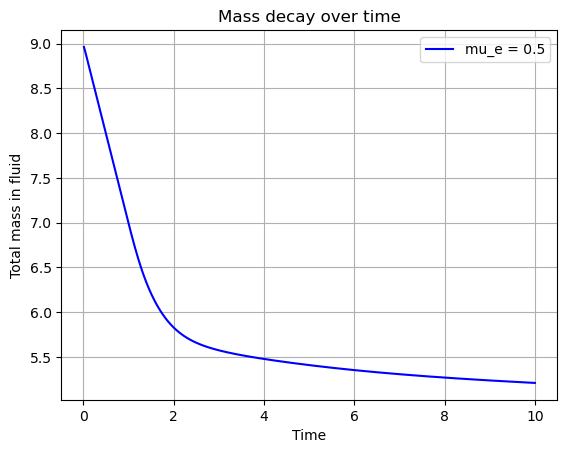

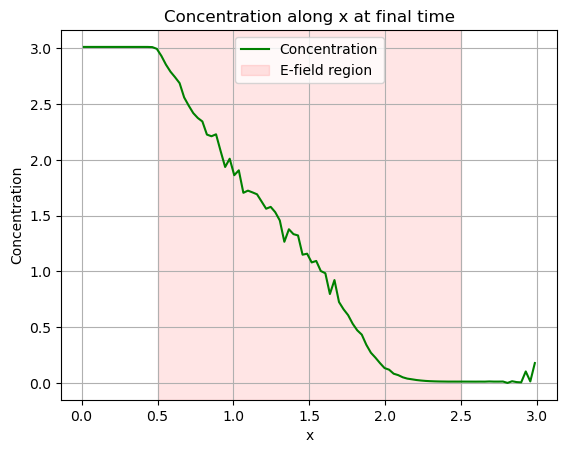

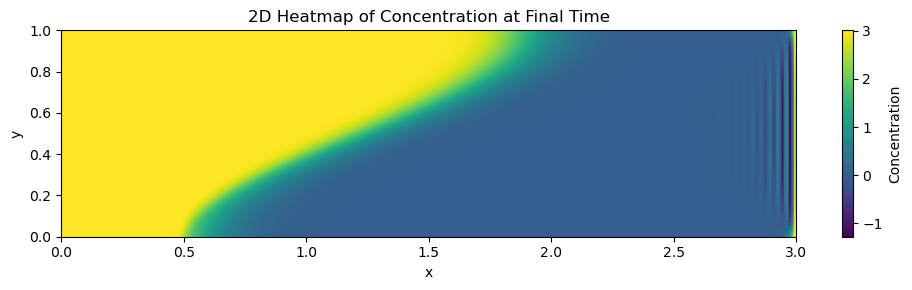

In [6]:
import netgen.meshing as meshing
from netgen.geom2d import SplineGeometry
from ngsolve import *
from ngsolve.solvers import GMRes
from ngsolve.la import BaseMatrix
from ngsolve.webgui import Draw

import numpy as np
import matplotlib.pyplot as plt


class IdentityPreconditioner(BaseMatrix):
    def __init__(self, size):
        super().__init__()
        self._size = size
    def Height(self): return self._size
    def Width(self):  return self._size
    def Mult(self, x, y): y.data = x


def SolveKineticDeposition_WithMassTracking(
    mesh,
    velocity_cf,
    E_cf,
    D=1e-3,
    mu_e=1e-1,
    dt=0.01,
    T=2.0,
    c0_value=3.0,
    kd=1.0
):
    fes_c = H1(mesh, order=1)
    c_gf = GridFunction(fes_c, "c")
    c_gf.Set(c0_value)

    u = fes_c.TrialFunction()
    v = fes_c.TestFunction()

    mass = BilinearForm(fes_c, symmetric=True)
    mass += u*v*dx
    mass.Assemble()

    drift_cf = velocity_cf + mu_e * E_cf

    a = BilinearForm(fes_c, symmetric=False)
    a += D * InnerProduct(grad(u), grad(v)) * dx
    a += (drift_cf * grad(u)) * v * dx
    a += kd * u * v * ds("wall")
    a.Assemble()

    mat = mass.mat.CreateMatrix()
    mat.AsVector().data = mass.mat.AsVector() + dt * a.mat.AsVector()

    pre = IdentityPreconditioner(mat.height)
    old_sol = c_gf.vec.CreateVector()
    old_sol.data = c_gf.vec
    rhs_vec = c_gf.vec.CreateVector()

    c_snapshots = [c_gf.vec.CreateVector()]
    c_snapshots[0].data = c_gf.vec

    times, deposit_history, mass_history = [], [], []
    lumps_deposit = 0.0

    nsteps = int(T / dt)
    for step in range(nsteps):
        tcur = (step + 1) * dt
        rhs_vec.data = mass.mat * old_sol
        c_gf.vec.data = 0.0 * c_gf.vec

        GMRes(A=mat, b=rhs_vec, x=c_gf.vec, pre=pre, maxsteps=1000,
              tol=1e-8, restart=1000, printrates=False)

        old_sol.data = c_gf.vec

        c_snapshots.append(c_gf.vec.CreateVector())
        c_snapshots[-1].data = c_gf.vec

        c_wall = Integrate(c_gf, mesh, BND, definedon=mesh.Boundaries("wall"))
        lumps_deposit += dt * kd * c_wall

        total_mass = Integrate(c_gf, mesh)
        times.append(tcur)
        deposit_history.append(lumps_deposit)
        mass_history.append(total_mass)

    return c_snapshots, fes_c, times, mass_history


# ✅ Manual polygon area (shoelace formula)
def polygon_area(vertices):
    x = [p[0] for p in vertices]
    y = [p[1] for p in vertices]
    return 0.5 * abs(sum(x[i]*y[(i+1)%len(vertices)] - x[(i+1)%len(vertices)]*y[i] for i in range(len(vertices))))

# ✅ Element-wise x-profile with manual area
def compute_mass_profile_along_x(gf, mesh, nx=100):
    x_bins = np.linspace(0, 3, nx+1)
    bin_totals = np.zeros(nx)
    bin_areas = np.zeros(nx)

    el_conc = Integrate(gf, mesh, element_wise=True)

    for el in mesh.Elements(VOL):
        vertex_coords = [mesh[vnr].point for vnr in el.vertices]
        x_center = sum(p[0] for p in vertex_coords) / len(vertex_coords)
        bin_index = np.searchsorted(x_bins, x_center) - 1
        if 0 <= bin_index < nx:
            area = polygon_area(vertex_coords)
            bin_totals[bin_index] += el_conc[el.nr]
            bin_areas[bin_index] += area

    x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])
    avg_concentration = np.divide(bin_totals, bin_areas, out=np.zeros_like(bin_totals), where=bin_areas > 0)
    return x_centers, avg_concentration


if __name__ == "__main__":
    # 1) Geometry
    geo = SplineGeometry()
    geo.AddRectangle((0, 0), (3, 1), bcs=["inflow", "wall", "outflow", "wall"])
    mesh = Mesh(geo.GenerateMesh(maxh=0.02))

    from ngsolve import x, y, IfPos

    velocity_cf = CoefficientFunction((4 * y * (1 - y), 0))
    E_switch = IfPos(x - 0.5, IfPos(2.5 - x, 1.0, 0.0), 0.0)
    E_cf = CoefficientFunction((0, E_switch))

    # 2) Run simulation
    mu_e = 0.5
    kd = 5.0
    T = 10.0

    print(f"\nRunning for mu_e = {mu_e}, kd = {kd}, T = {T}")
    c_snapshots, fes_c, times, mass_history = SolveKineticDeposition_WithMassTracking(
        mesh=mesh,
        velocity_cf=velocity_cf,
        E_cf=E_cf,
        D=1e-3,
        mu_e=mu_e,
        dt=0.01,
        T=T,
        c0_value=3.0,
        kd=kd
    )

    # 3) Plot mass decay over time
    plt.figure()
    plt.plot(times, mass_history, label=f"mu_e = {mu_e}", color='blue')
    plt.xlabel("Time")
    plt.ylabel("Total mass in fluid")
    plt.title("Mass decay over time")
    plt.grid(True)
    plt.legend()
    plt.savefig("mass_decay_overtime.png")
    plt.show()

    # 4) Final corrected concentration plot (called 'concentration')
    final_c = GridFunction(fes_c, name="final_c")
    final_c.vec.data = c_snapshots[-1]

    x_centers, avg_concentration = compute_mass_profile_along_x(final_c, mesh)
    concentration = np.max(avg_concentration) - avg_concentration

    plt.figure()
    plt.plot(x_centers, concentration, color='green', label='Concentration')
    plt.axvspan(0.5, 2.5, color='red', alpha=0.1, label="E-field region")
    plt.title("Concentration along x at final time")
    plt.xlabel("x")
    plt.ylabel("Concentration")
    plt.grid(True)
    plt.legend()
    plt.savefig("concentration_profile.png")
    plt.show()

    # 2D heatmap of concentration(x, y) = max_c0 - final_c(x, y)
    Nx, Ny = 300, 100
    x_vals = np.linspace(0, 3.0, Nx)
    y_vals = np.linspace(0, 1.0, Ny)
    X, Y = np.meshgrid(x_vals, y_vals)

    points = list(zip(X.ravel(), Y.ravel()))
    max_c0 = 3.0  # initial concentration everywhere

    # Evaluate final concentration at all points
    values = np.array([final_c(x, y) for (x, y) in points])
    values = values.reshape(Y.shape)
    concentration_2d = max_c0 - values

    # Plot heatmap
    plt.figure(figsize=(10, 3))
    plt.imshow(
        concentration_2d,
        origin='lower',
        extent=(0, 3.0, 0, 1.0),
        aspect='auto',
        cmap='viridis'
    )
    plt.colorbar(label="Concentration")
    plt.title("2D Heatmap of Concentration at Final Time")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.savefig("concentration_heatmap_2d.png")
    plt.show()

In [ ]:
# TODO:
# Add some docs for different parameters to make it easier to test
# Figure out how I can quantify the amount of water exiting the system and concentration of that water.
# Gitt lengde på rør og trykk (hastighet), hva er laveste energi (E-feltstyrke) som kan brukes for å oppnå ønsket filtrering? ​
# Vi trenger kanskje også å spesifisere ting som mengde med vann vi skal filtrere eller mengde med tid.
# Lengde på rør : 1, trykk gitt ved